In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    f1_score, roc_auc_score, classification_report
)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM


In [2]:
import numpy as np
print(np.__version__)

1.26.4


In [3]:
!pip uninstall tensorflow -y
!pip install tensorflow-macos
!pip install tensorflow-metal

Found existing installation: tensorflow 2.16.2
Uninstalling tensorflow-2.16.2:
  Successfully uninstalled tensorflow-2.16.2
  Using cached tensorflow-2.16.2-cp312-cp312-macosx_12_0_arm64.whl.metadata (4.1 kB)
Using cached tensorflow-2.16.2-cp312-cp312-macosx_12_0_arm64.whl (227.1 MB)


In [4]:
DELHI_CSV_PATH   = "/Users/manis/Downloads/punjabi-bagh, delhi-air-quality.csv"
BEIJING_CSV_PATH = "/Users/manis/Downloads/beijing-air-quality.csv"  # <-- update if you have it

DATE_COL_CANDIDATES = ["date", "Date", "datetime", "Datetime", "timestamp", "Timestamp"]

# PM2.5 threshold for binary "unsafe" decision
PM25_THRESHOLD = 150 # You can tune this and justify in report

# LSTM settings
LOOKBACK = 14
EPOCHS = 30
BATCH_SIZE = 32
SEED = 42


In [5]:

def find_date_col(df):
    for c in DATE_COL_CANDIDATES:
        if c in df.columns:
            return c
    for c in df.columns:
        if "date" in c.lower() or "time" in c.lower():
            return c
    raise ValueError("Could not find a date/datetime column. Please set DATE_COL_CANDIDATES or rename your column to 'date'.")

def standardize_columns(df):
    # lower-case + strip spaces (keeps punctuation like '.' so pm2.5 stays pm2.5)
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    return df

def coerce_numeric(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def coalesce_columns(df, candidates, out_col):
    """Create out_col by taking the first non-null value across candidate columns (if they exist)."""
    existing = [c for c in candidates if c in df.columns]
    if not existing:
        return df
    out = None
    for c in existing:
        if out is None:
            out = df[c]
        else:
            out = out.combine_first(df[c])
    df[out_col] = out
    # Drop all candidate cols except out_col itself (avoid duplicated column names)
    to_drop = [c for c in existing if c != out_col and c in df.columns]
    if to_drop:
        df = df.drop(columns=to_drop)
    return df

def harmonize_pollutants(df):
    """Unify common pollutant column-name variants into one canonical name (pm25, pm10, no2, so2, co, o3)."""
    df = df.copy()
    # PM2.5 variants
    df = coalesce_columns(df, ["pm25","pm2.5","pm_2_5","pm2_5","pm 2.5","pm-2.5"], "pm25")
    # PM10 variants
    df = coalesce_columns(df, ["pm10","pm_10","pm-10","pm 10"], "pm10")
    # other gases
    df = coalesce_columns(df, ["no2","no_2","no-2","nitrogen dioxide"], "no2")
    df = coalesce_columns(df, ["so2","so_2","so-2","sulfur dioxide","sulphur dioxide"], "so2")
    df = coalesce_columns(df, ["co","carbon monoxide"], "co")
    df = coalesce_columns(df, ["o3","o_3","o-3","ozone"], "o3")
    return df

def load_air_quality(csv_path):
    df = pd.read_csv(csv_path)
    df = standardize_columns(df)

    # find + parse date
    date_col = find_date_col(df)
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.rename(columns={date_col: "date"})
    df = df.dropna(subset=["date"]).sort_values("date")

    # unify pollutant names WITHOUT creating duplicates
    df = harmonize_pollutants(df)

    # keep only relevant cols if present
    keep = ["date", "pm25", "pm10", "no2", "so2", "co", "o3"]
    existing = [c for c in keep if c in df.columns]
    df = df[existing].copy()

    # ensure numeric
    df = coerce_numeric(df, ["pm25","pm10","no2","so2","co","o3"])

    # daily aggregation (if multiple readings per day)
    df["date"] = df["date"].dt.floor("D")
    df = df.groupby("date", as_index=False).mean(numeric_only=True)

    return df

delhi_df = load_air_quality(DELHI_CSV_PATH)
print("Delhi shape:", delhi_df.shape)
print(delhi_df.head())

beijing_df = None
if BEIJING_CSV_PATH is not None:
    try:
        beijing_df = load_air_quality(BEIJING_CSV_PATH)
        print("Beijing shape:", beijing_df.shape)
        print(beijing_df.head())
    except Exception as e:
        print("Beijing file not loaded (optional):", e)
        beijing_df = None


Delhi shape: (4150, 7)
        date   pm25   pm10   no2  so2    co    o3
0 2014-01-01    NaN  239.0  21.0  7.0  23.0  11.0
1 2014-01-02  288.0  210.0  22.0  5.0  26.0  20.0
2 2014-01-03  266.0  286.0  33.0  6.0  36.0  21.0
3 2014-01-04  292.0  660.0  51.0  6.0  32.0   7.0
4 2014-01-05  465.0  657.0  36.0  6.0  23.0  11.0
Beijing shape: (4380, 7)
        date   pm25   pm10   no2   so2    co    o3
0 2014-01-01    NaN   85.0  30.0  14.0  20.0  20.0
1 2014-01-02  125.0  136.0  44.0  45.0  39.0   4.0
2 2014-01-03  218.0   79.0  20.0  15.0  22.0  22.0
3 2014-01-04  127.0  109.0  37.0  26.0  32.0   3.0
4 2014-01-05  213.0   74.0  32.0  23.0  24.0  16.0


In [6]:
# ---------------------------
# 3) Clean missing data (simple, explainable)
# ---------------------------
def clean_missing_time_series(df):
    df = df.sort_values("date").copy()
    
    # Set the date column as the index for time-based interpolation
    df = df.set_index("date")
    
    # forward fill then backward fill for remaining gaps (time series friendly)
    for c in df.columns:
        df[c] = df[c].interpolate(method="time", limit_direction="both")
        df[c] = df[c].ffill().bfill()
    
    # Reset index to get the date back as a column
    df = df.reset_index()
    
    return df

delhi_df = clean_missing_time_series(delhi_df)
if beijing_df is not None:
    beijing_df = clean_missing_time_series(beijing_df)

In [7]:
# ---------------------------
# 4) Feature engineering (lags, rolls, calendar)
# ---------------------------
def add_ml_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values("date").copy()

    # calendar features
    df["month"] = df["date"].dt.month
    df["dayofweek"] = df["date"].dt.dayofweek
    df["is_winter"] = df["month"].isin([11,12,1,2]).astype(int)

    # --- PM2.5 lags
    df["pm25_lag1"] = df["pm25"].shift(1)
    df["pm25_lag7"] = df["pm25"].shift(7)
    df["pm25_lag14"] = df["pm25"].shift(14)
    
    # --- PM2.5 rolling
    df["pm25_roll3"]  = df["pm25"].rolling(3).mean()
    df["pm25_roll7"]  = df["pm25"].rolling(7).mean()
    df["pm25_roll14"] = df["pm25"].rolling(14).mean()
    df["pm25_std7"]   = df["pm25"].rolling(7).std()

    # Rolling for other pollutants if available
    for col in ["pm10","no2","so2","co","o3"]:
        if col in df.columns:
            df[f"{col}_roll7"] = df[col].rolling(7).mean()

    # Tomorrow target
    df["pm25_tomorrow"] = df["pm25"].shift(-1)

    return df

delhi_ml = add_ml_features(delhi_df).dropna().reset_index(drop=True)
print("\nAfter features (Delhi):", delhi_ml.shape)

beijing_ml = None
if beijing_df is not None:
    beijing_ml = add_ml_features(beijing_df).dropna().reset_index(drop=True)
    print("After features (Beijing):", beijing_ml.shape)

# Binary label for notifications
delhi_ml["unsafe_tomorrow"] = (delhi_ml["pm25_tomorrow"] >= PM25_THRESHOLD).astype(int)



After features (Delhi): (4135, 23)
After features (Beijing): (4365, 23)


In [8]:
# ---------------------------
# 5) Train/Test split (time-based)
# ---------------------------
cutoff_date = delhi_ml["date"].quantile(0.80)
train = delhi_ml[delhi_ml["date"] <= cutoff_date].copy()
test  = delhi_ml[delhi_ml["date"] > cutoff_date].copy()

print("\nTrain range:", train["date"].min(), "to", train["date"].max(), "rows:", len(train))
print("Test  range:", test["date"].min(),  "to", test["date"].max(),  "rows:", len(test))



Train range: 2014-01-15 00:00:00 to 2023-09-11 00:00:00 rows: 3308
Test  range: 2023-09-12 00:00:00 to 2026-01-05 00:00:00 rows: 827


In [9]:
# ============================================================
# PART A: REGRESSION (Forecast tomorrow's PM2.5)
# Models: Naive baseline, RandomForestRegressor, SARIMAX, LSTM
# ============================================================

# ---------------------------
# 6A) Naive baseline
# ---------------------------
y_test_reg = test["pm25_tomorrow"].values
pred_naive = test["pm25"].values  # tomorrow = today

rmse_naive = np.sqrt(mean_squared_error(y_test_reg, pred_naive))
mae_naive  = mean_absolute_error(y_test_reg, pred_naive)
r2_naive   = r2_score(y_test_reg, pred_naive)

In [10]:

# ---------------------------
# 6B) RandomForestRegressor (with hyper-parameter tuning using TimeSeriesSplit)
# NOTE: Random Forest is not a time-series model by itself. We make it a forecaster
# by using lag/rolling features so the model learns patterns from the past to predict t+1.
# ---------------------------
from sklearn.model_selection import RandomizedSearchCV

REG_FEATURES = [
    "pm25","pm25_lag1","pm25_lag7","pm25_roll7","pm25_roll14","pm25_std7",
    "month","dayofweek","is_winter"
]
for col in ["pm10","no2","so2","co","o3"]:
    if col in delhi_ml.columns:
        REG_FEATURES.append(col)

X_train_reg = train[REG_FEATURES]
y_train_reg = train["pm25_tomorrow"]
X_test_reg  = test[REG_FEATURES]
y_test_reg  = test["pm25_tomorrow"].values

# --- Hyper-parameter tuning (time-series safe CV) ---
tss = TimeSeriesSplit(n_splits=5)

param_dist = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", 0.5, 1.0],
    "bootstrap": [True],
}

base_rfr = RandomForestRegressor(random_state=SEED, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=base_rfr,
    param_distributions=param_dist,
    n_iter=30,
    cv=tss,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=-1,
    verbose=0
)

search.fit(X_train_reg, y_train_reg)
rfr = search.best_estimator_

print("Best RF params:", search.best_params_)
print("CV RMSE (best):", -search.best_score_)

# Fit on full train and forecast on test (future/unseen)
rfr.fit(X_train_reg, y_train_reg)
pred_rfr_test = rfr.predict(X_test_reg)

rmse_rfr = np.sqrt(mean_squared_error(y_test_reg, pred_rfr_test))
mae_rfr  = mean_absolute_error(y_test_reg, pred_rfr_test)
r2_rfr   = r2_score(y_test_reg, pred_rfr_test)

print(f"RF Test RMSE={rmse_rfr:.3f} | MAE={mae_rfr:.3f} | R2={r2_rfr:.3f}")

# --- Walk-forward backtest predictions on TRAIN (to compare train vs test fairly) ---
train_oof_pred = np.full(shape=len(train), fill_value=np.nan)

for fold, (tr_idx, val_idx) in enumerate(tss.split(X_train_reg), start=1):
    X_tr, y_tr = X_train_reg.iloc[tr_idx], y_train_reg.iloc[tr_idx]
    X_val      = X_train_reg.iloc[val_idx]

    # Use the same best params found above, but fit only on the fold's training part
    fold_rfr = RandomForestRegressor(**search.best_params_, random_state=SEED, n_jobs=-1)
    fold_rfr.fit(X_tr, y_tr)
    train_oof_pred[val_idx] = fold_rfr.predict(X_val)

# Metrics on train backtest (out-of-fold)
valid_mask = ~np.isnan(train_oof_pred)
rmse_rfr_train = np.sqrt(mean_squared_error(y_train_reg.values[valid_mask], train_oof_pred[valid_mask]))
mae_rfr_train  = mean_absolute_error(y_train_reg.values[valid_mask], train_oof_pred[valid_mask])
r2_rfr_train   = r2_score(y_train_reg.values[valid_mask], train_oof_pred[valid_mask])

print(f"RF Train Backtest RMSE={rmse_rfr_train:.3f} | MAE={mae_rfr_train:.3f} | R2={r2_rfr_train:.3f}")

# --- Baselines to explain negative R2 if it happens ---
# Baseline 1: predict tomorrow = today
pred_naive_test = test["pm25"].values
r2_naive_test = r2_score(y_test_reg, pred_naive_test)
rmse_naive_test = np.sqrt(mean_squared_error(y_test_reg, pred_naive_test))
print(f"Naive (tomorrow=today) Test RMSE={rmse_naive_test:.3f} | R2={r2_naive_test:.3f}")


Best RF params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None, 'bootstrap': True}
CV RMSE (best): 29.836197197497768
RF Test RMSE=28.343 | MAE=18.287 | R2=0.897
RF Train Backtest RMSE=30.123 | MAE=20.106 | R2=0.874
Naive (tomorrow=today) Test RMSE=44.325 | R2=0.747


In [12]:
# Import the required libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define constants if not already defined
SEED = 42
LOOKBACK = 7  # Adjust this value as needed
EPOCHS = 10   # Adjust this value as needed
BATCH_SIZE = 32  # Adjust this value as needed

# ---------------------------
# 6D) LSTM Regression 
# ---------------------------
tf.random.set_seed(SEED)
np.random.seed(SEED)

LSTM_FEATURES = ["pm25","pm10","no2","so2","co","o3","month","is_winter","dayofweek"]
LSTM_FEATURES = [c for c in LSTM_FEATURES if c in delhi_ml.columns]

scaler_lstm = StandardScaler()
train_X_raw = scaler_lstm.fit_transform(train[LSTM_FEATURES])
test_X_raw  = scaler_lstm.transform(test[LSTM_FEATURES])

train_y_raw = train["pm25_tomorrow"].values
test_y_raw  = test["pm25_tomorrow"].values

def make_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = make_sequences(train_X_raw, train_y_raw, LOOKBACK)
X_test_seq,  y_test_seq  = make_sequences(test_X_raw,  test_y_raw,  LOOKBACK)

lstm_model = models.Sequential([
    layers.Input(shape=(LOOKBACK, X_train_seq.shape[2])),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mse")

hist = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

pred_lstm = lstm_model.predict(X_test_seq).ravel()

rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, pred_lstm))
mae_lstm  = mean_absolute_error(y_test_seq, pred_lstm)
r2_lstm   = r2_score(y_test_seq, pred_lstm)

2026-02-18 12:44:44.365909: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-02-18 12:44:44.366077: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-02-18 12:44:44.366085: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-02-18 12:44:44.366969: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-18 12:44:44.367133: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/10


2026-02-18 12:44:45.837642: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-02-18 12:44:45.841385: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 38535.5156 - val_loss: 31043.9434
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 23439.6094 - val_loss: 14659.0801
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 11689.0068 - val_loss: 7459.4448
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7454.7104 - val_loss: 6023.3838
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5884.7578 - val_loss: 3851.7148
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4123.7891 - val_loss: 2901.0945
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3434.9973 - val_loss: 2480.3833
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2993.8384 - val_loss: 2232.5498
Epoch 9/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2772.6289 - val_loss: 2078.4089
Epoch 10/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2652.7690 - val_loss: 1992.8281
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [21]:
leader_reg = pd.DataFrame([
    {"model":"Naive (tomorrow=today)", "RMSE": rmse_naive, "MAE": mae_naive, "R2": r2_naive},
    {"model":"RandomForestRegressor",  "RMSE": rmse_rfr,   "MAE": mae_rfr,   "R2": r2_rfr},
    {"model":"LSTM (regression)",      "RMSE": rmse_lstm,  "MAE": mae_lstm,  "R2": r2_lstm},
]).sort_values("RMSE")

print("\n=== Regression Leaderboard (lower RMSE/MAE is better) ===")
print(leader_reg)


=== Regression Leaderboard (lower RMSE/MAE is better) ===
                    model       RMSE        MAE        R2
1   RandomForestRegressor  28.342732  18.286967  0.896651
0  Naive (tomorrow=today)  44.324796  29.654172  0.747236
2       LSTM (regression)  50.558062  35.017513  0.672102


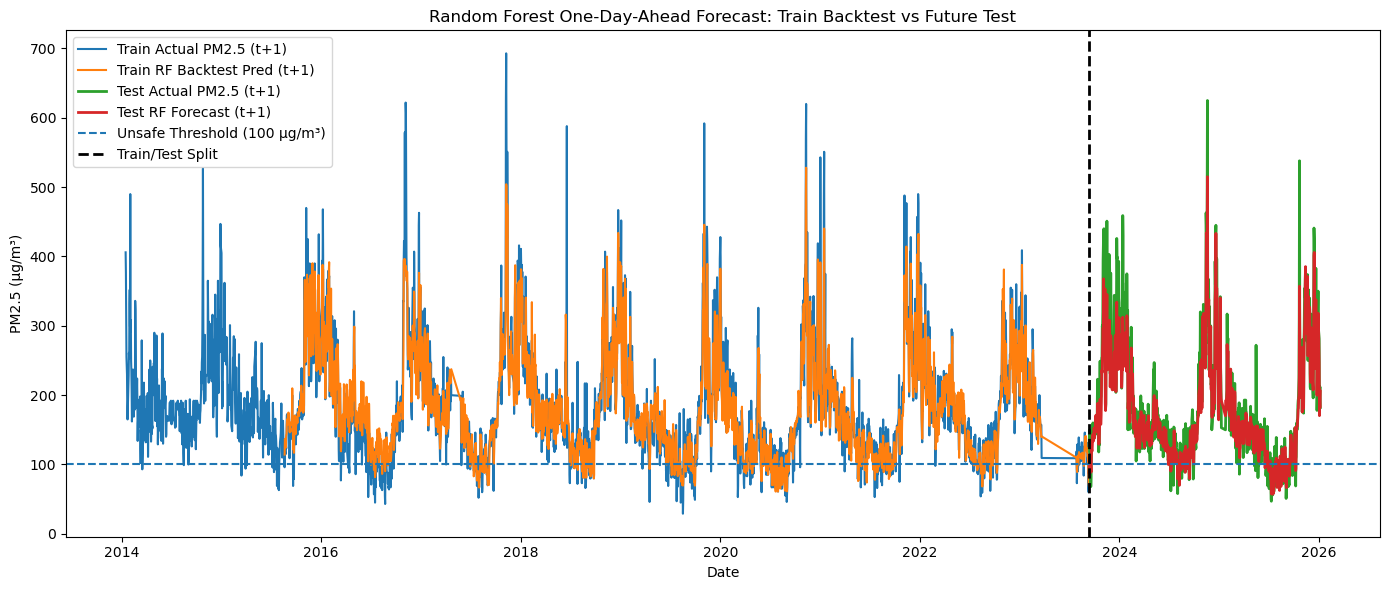

In [29]:

# ---------------------------
# Visualization: Random Forest (Train backtest vs Test future)
# ---------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Train (backtest) - align by date
train_dates = train["date"].values
plt.plot(train_dates, train["pm25_tomorrow"].values, label="Train Actual PM2.5 (t+1)", linewidth=1.5)
plt.plot(train_dates, train_oof_pred, label="Train RF Backtest Pred (t+1)", linewidth=1.5)

# Test (future/unseen)
test_dates = test["date"].values
plt.plot(test_dates, y_test_reg, label="Test Actual PM2.5 (t+1)", linewidth=2)
plt.plot(test_dates, pred_rfr_test, label="Test RF Forecast (t+1)", linewidth=2)

# Unsafe threshold
plt.axhline(100, linestyle="--", linewidth=1.5, label="Unsafe Threshold (100 µg/m³)")
plt.axvline(x=test["date"].iloc[0], 
            color='black', linestyle='--', linewidth=2,
            label="Train/Test Split")

plt.title("Random Forest One-Day-Ahead Forecast: Train Backtest vs Future Test")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()
plt.show()


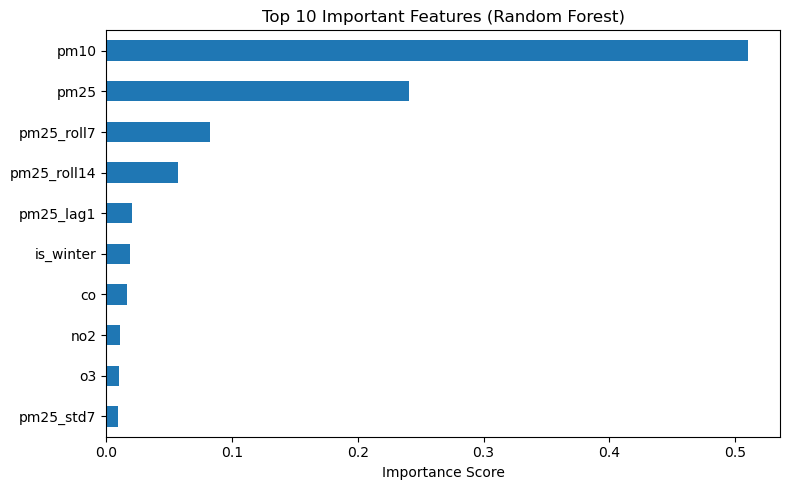

In [15]:
# Feature Importance


importance = pd.Series(rfr.feature_importances_, index=REG_FEATURES)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.head(10).plot(kind="barh")
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Best RF-CLF params: {'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}

=== Classification Leaderboard (higher F1 is better) ===
                    model        F1       AUC
1  RandomForestClassifier  0.884324  0.962242
0      LogisticRegression  0.858783  0.960007

RandomForest Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       340
           1       0.93      0.84      0.88       487

    accuracy                           0.87       827
   macro avg       0.87      0.88      0.87       827
weighted avg       0.88      0.87      0.87       827



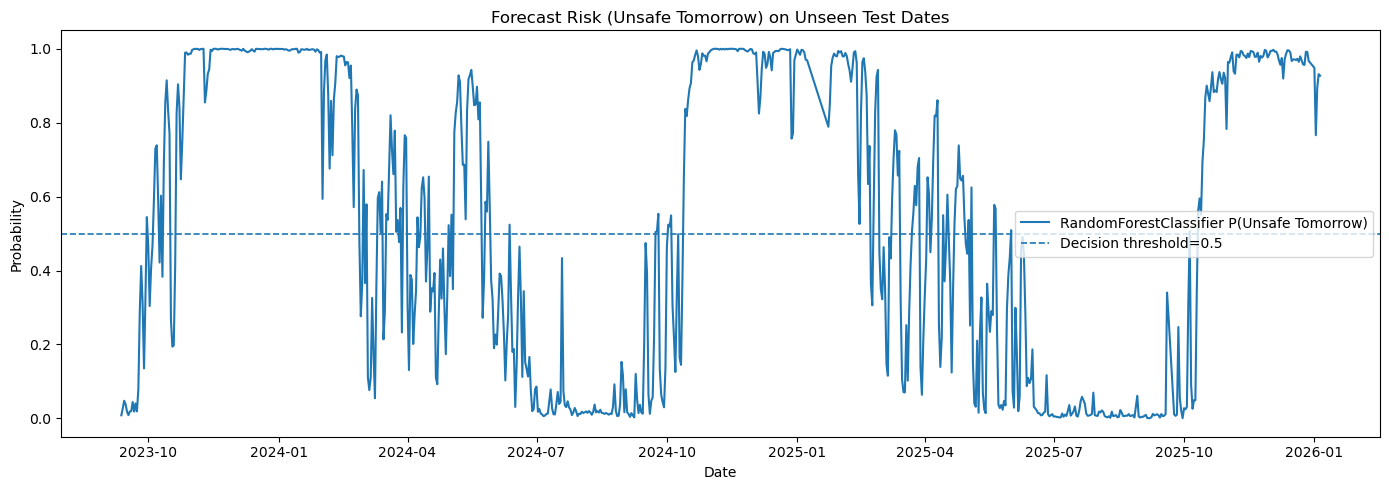

In [16]:

# ============================================================
# PART B: SUPERVISED BINARY RISK (Unsafe vs Safe) FOR TOMORROW
# Models: LogisticRegression, RandomForestClassifier
# Target: unsafe_tomorrow (uses pm25_tomorrow >= threshold) so it IS forecasting t+1.
# ============================================================

CLF_FEATURES = [
    "pm25","pm25_lag1","pm25_roll7","pm25_roll14","pm25_std7",
    "month","dayofweek","is_winter"
]
for col in ["pm10","no2","so2","co","o3"]:
    if col in delhi_ml.columns:
        CLF_FEATURES.append(col)

X_train_clf = train[CLF_FEATURES]
y_train_clf = train["unsafe_tomorrow"]
X_test_clf  = test[CLF_FEATURES]
y_test_clf  = test["unsafe_tomorrow"]

# --- Logistic Regression (scaled) ---
sc_clf = StandardScaler()
X_train_lr = sc_clf.fit_transform(X_train_clf)
X_test_lr  = sc_clf.transform(X_test_clf)

lr = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED)
lr.fit(X_train_lr, y_train_clf)
pred_lr = lr.predict(X_test_lr)
proba_lr = lr.predict_proba(X_test_lr)[:,1]

f1_lr = f1_score(y_test_clf, pred_lr)
auc_lr = roc_auc_score(y_test_clf, proba_lr)

# --- Random Forest Classifier (tuned lightly) ---
from sklearn.model_selection import RandomizedSearchCV

rf_base = RandomForestClassifier(random_state=SEED, class_weight="balanced", n_jobs=-1)

param_dist_clf = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 1.0],
}

tss = TimeSeriesSplit(n_splits=5)
search_clf = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist_clf,
    n_iter=20,
    cv=tss,
    scoring="f1",
    random_state=SEED,
    n_jobs=-1,
    verbose=0
)
search_clf.fit(X_train_clf, y_train_clf)
rf = search_clf.best_estimator_

print("Best RF-CLF params:", search_clf.best_params_)
rf.fit(X_train_clf, y_train_clf)

pred_rf = rf.predict(X_test_clf)
proba_rf = rf.predict_proba(X_test_clf)[:,1]

f1_rf = f1_score(y_test_clf, pred_rf)
auc_rf = roc_auc_score(y_test_clf, proba_rf)

leader_clf = pd.DataFrame([
    {"model":"LogisticRegression",    "F1": f1_lr, "AUC": auc_lr},
    {"model":"RandomForestClassifier","F1": f1_rf, "AUC": auc_rf},
]).sort_values("F1", ascending=False)

print("\n=== Classification Leaderboard (higher F1 is better) ===")
print(leader_clf)

print("\nRandomForest Classification Report:")
print(classification_report(y_test_clf, pred_rf))

best_clf_name = leader_clf.iloc[0]["model"]
best_clf = rf if best_clf_name == "RandomForestClassifier" else lr
best_clf_proba_test = proba_rf if best_clf_name == "RandomForestClassifier" else proba_lr

# --- Plot classification probability on the FUTURE test period (time-series view) ---
plt.figure(figsize=(14,5))
plt.plot(test["date"], best_clf_proba_test, label=f"{best_clf_name} P(Unsafe Tomorrow)")
plt.axhline(0.5, linestyle="--", linewidth=1.2, label="Decision threshold=0.5")
plt.title("Forecast Risk (Unsafe Tomorrow) on Unseen Test Dates")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
# ============================================================
# PART C: UNSUPERVISED ANOMALY / NOVELTY DETECTION
# Models: IsolationForest, One-Class SVM
# Idea: Fit on Beijing (normal), score Delhi (novel) if Beijing data exists
# If Beijing not available: fit on early Delhi period as "baseline normal"
# ============================================================

UNSUP_FEATURES = []
for c in ["pm10","no2","so2","co","o3","pm25_roll7"]:
    if c in delhi_ml.columns:
        UNSUP_FEATURES.append(c)
for c in ["pm10_roll7","no2_roll7","o3_roll7"]:
    if c in delhi_ml.columns:
        UNSUP_FEATURES.append(c)

# fallback if too few columns
if len(UNSUP_FEATURES) < 2:
    UNSUP_FEATURES = ["pm25","pm25_roll7","pm25_std7"]

sc_unsup = StandardScaler()

if beijing_ml is not None:
    X_base = sc_unsup.fit_transform(beijing_ml[UNSUP_FEATURES])
    X_eval = sc_unsup.transform(delhi_ml[UNSUP_FEATURES])
    base_name = "Beijing (baseline normal)"
else:
    # use first 60% of Delhi as baseline normal
    baseline_cutoff = delhi_ml["date"].quantile(0.60)
    base = delhi_ml[delhi_ml["date"] <= baseline_cutoff]
    X_base = sc_unsup.fit_transform(base[UNSUP_FEATURES])
    X_eval = sc_unsup.transform(delhi_ml[UNSUP_FEATURES])
    base_name = "Early Delhi (baseline normal)"

print("\nUnsupervised baseline:", base_name)
print("Unsupervised features:", UNSUP_FEATURES)

# Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=SEED)
iso.fit(X_base)
# sklearn: -1 anomaly, +1 normal
delhi_ml["isoforest_flag"] = iso.predict(X_eval)

# One-Class SVM
ocsvm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
ocsvm.fit(X_base)
delhi_ml["ocsvm_flag"] = ocsvm.predict(X_eval)

# Proxy evaluation: do anomalies concentrate on high PM2.5 days?
q90 = delhi_ml["pm25"].quantile(0.90)
delhi_ml["is_high_pm25"] = (delhi_ml["pm25"] >= q90).astype(int)

def anomaly_rate(df, flag_col):
    hi = df[df["is_high_pm25"]==1]
    lo = df[df["is_high_pm25"]==0]
    hi_rate = (hi[flag_col]==-1).mean()
    lo_rate = (lo[flag_col]==-1).mean()
    return hi_rate, lo_rate, (hi_rate - lo_rate)

iso_hi, iso_lo, iso_sep = anomaly_rate(delhi_ml, "isoforest_flag")
svm_hi, svm_lo, svm_sep = anomaly_rate(delhi_ml, "ocsvm_flag")

print("\n=== Unsupervised Proxy Evaluation (higher separation is better) ===")
print(f"IsolationForest | highPM anomaly rate={iso_hi:.3f}, normalPM anomaly rate={iso_lo:.3f}, separation={iso_sep:.3f}")
print(f"OneClassSVM     | highPM anomaly rate={svm_hi:.3f}, normalPM anomaly rate={svm_lo:.3f}, separation={svm_sep:.3f}")

best_unsup = "IsolationForest" if iso_sep >= svm_sep else "OneClassSVM"
print("\nBest unsupervised by proxy-separation:", best_unsup)

# Show top anomalous days (either model)
anom_days = delhi_ml.copy()
anom_days["anomaly_votes"] = (anom_days["isoforest_flag"]==-1).astype(int) + (anom_days["ocsvm_flag"]==-1).astype(int)
anom_days = anom_days.sort_values(["anomaly_votes","pm25"], ascending=[False, False]).head(20)

print("\nTop 20 'most anomalous' Delhi days (votes + high pm25):")
print(anom_days[["date","pm25","pm10" if "pm10" in anom_days.columns else "pm25",
                 "anomaly_votes","isoforest_flag","ocsvm_flag"]].head(20))



Unsupervised baseline: Beijing (baseline normal)
Unsupervised features: ['pm10', 'no2', 'so2', 'co', 'o3', 'pm25_roll7', 'pm10_roll7', 'no2_roll7', 'o3_roll7']

=== Unsupervised Proxy Evaluation (higher separation is better) ===
IsolationForest | highPM anomaly rate=1.000, normalPM anomaly rate=0.410, separation=0.590
OneClassSVM     | highPM anomaly rate=1.000, normalPM anomaly rate=0.485, separation=0.515

Best unsupervised by proxy-separation: IsolationForest

Top 20 'most anomalous' Delhi days (votes + high pm25):
           date   pm25   pm10  anomaly_votes  isoforest_flag  ocsvm_flag
1318 2017-11-09  693.0  783.0              2              -1          -1
1317 2017-11-08  625.0  941.0              2              -1          -1
3742 2024-11-19  625.0  272.0              2              -1          -1
985  2016-11-06  622.0  914.0              2              -1          -1
2402 2020-11-11  620.0  377.0              2              -1          -1
986  2016-11-07  607.0  598.0        

In [18]:
# ============================================================
# PART D: CIVILIAN NOTIFICATION FUNCTION (final output)
# Uses best supervised binary model to print clear guidance
# ============================================================



In [ ]:
# ============================================================
# CIVILIAN NOTIFICATION SYSTEM (DROP-IN, WORKING)
# ------------------------------------------------------------
# What this does:
# 1) Takes your trained regression model (e.g., RandomForestRegressor 'rfr')
# 2) Finds the latest available date in your engineered ML dataframe (delhi_ml)
# 3) Extracts the SAME feature columns used in training (REG_FEATURES)
# 4) Forecasts tomorrow PM2.5 (one-step ahead: t -> t+1)
# 5) Prints a presentable public-facing alert (stay indoors, wear mask, etc.)
# ============================================================

import numpy as np
import pandas as pd

def forecast_tomorrow_pm25_regression(reg_model, latest_row_df, reg_feature_cols):
    """
    Forecasts tomorrow PM2.5 using a trained regression model and the latest feature row.
    latest_row_df must be a 1-row DataFrame that already contains lag/rolling/calendar features.
    """
    if not isinstance(latest_row_df, pd.DataFrame) or len(latest_row_df) != 1:
        raise ValueError("latest_row_df must be a 1-row pandas DataFrame.")

    # Check required features exist
    missing = [c for c in reg_feature_cols if c not in latest_row_df.columns]
    if missing:
        raise ValueError(
            "Latest row is missing required features:\n- "
            + "\n- ".join(missing)
            + "\n\nFix: make sure you computed lag/rolling features inside delhi_ml "
              "BEFORE calling this alert system."
        )

    X_latest = latest_row_df[reg_feature_cols].copy()

    # Enforce numeric
    for c in X_latest.columns:
        X_latest[c] = pd.to_numeric(X_latest[c], errors="coerce")

    # No NaNs allowed
    if X_latest.isna().any().any():
        bad_cols = X_latest.columns[X_latest.isna().any()].tolist()
        raise ValueError(
            "NaNs found in latest feature row for columns:\n- "
            + "\n- ".join(bad_cols)
            + "\n\nFix: your latest date may not have enough history for rolling windows. "
              "Try using smaller windows or ensure enough past data exists."
        )

    yhat = reg_model.predict(X_latest)[0]
    return float(yhat)


def civilian_notification_from_forecast(tomorrow_pm25_forecast, today_pm25, pm25_threshold=150):
    """
    Prints a professional, citizen-friendly air-quality alert message
    based on tomorrow PM2.5 forecast.
    """

    # Optional: quick severity bands (for nicer messaging)
    def severity_band(x):
        if x >= 300: return "HAZARDOUS"
        if x >= 200: return "VERY UNHEALTHY"
        if x >= 150: return "UNHEALTHY"
        if x >= 100: return "UNHEALTHY (SENSITIVE)"
        if x >= 60:  return "MODERATE"
        return "GOOD"

    sev = severity_band(tomorrow_pm25_forecast)

    print("\n" + "="*66)
    print("                 DELHI AIR QUALITY CIVILIAN ALERT")
    print("="*66)

    print(f"\n📅 Latest observed day PM2.5: {today_pm25:.1f} µg/m³")
    print(f"📈 Forecast for tomorrow PM2.5: {tomorrow_pm25_forecast:.1f} µg/m³")
    print(f"🏷  Forecast severity: {sev}")
    print(f"⚠️  Unsafe threshold used in project: {pm25_threshold} µg/m³\n")

    if tomorrow_pm25_forecast >= pm25_threshold:
        print("🚨 ALERT STATUS: UNSAFE AIR EXPECTED TOMORROW")
        print("\n✅ Recommended Actions (Public Health Guidance):")
        print("• 🏠 Stay indoors as much as possible; limit time outside.")
        print("• 😷 If you must go out, wear an N95/KN95 mask (cloth masks help less).")
        print("• 🚫 Avoid running, gym, or heavy outdoor exercise.")
        print("• 🪟 Keep windows closed; use an air purifier if available.")
        print("• 🧒👵 High-risk groups (children, elderly, asthma/COPD patients) should take extra care.")
        print("• 💧 Stay hydrated; watch for symptoms (coughing, wheezing, chest tightness).")
        print("\n📢 Advisory: Reduce exposure until conditions improve.")
    else:
        print("✅ ALERT STATUS: SAFE / MODERATE CONDITIONS TOMORROW")
        print("\n✅ Recommended Actions:")
        print("• 🌤 Normal activities are acceptable for most people.")
        print("• 😷 Sensitive individuals may wear a mask if irritation occurs.")
        print("• 🏃 Outdoor exercise is generally okay under normal precautions.")
        print("• 📲 Continue monitoring daily air-quality updates.")
        print("\n📢 Advisory: Stay informed—pollution can change quickly.")

    print("\n🔎 Note: This alert is generated from a trained ML forecasting model (t → t+1).")
    print("="*66 + "\n")


def run_citizen_alert_system(reg_model, delhi_ml, reg_feature_cols, pm25_threshold=150):
    """
    Main function you call.
    - reg_model: trained regression model (e.g., rfr)
    - delhi_ml: your engineered dataframe containing 'date', 'pm25', and all REG_FEATURES
    - reg_feature_cols: list of feature column names used in training
    - pm25_threshold: unsafe threshold used in your project
    Returns: tomorrow forecast value (float)
    """
    if "date" not in delhi_ml.columns:
        raise ValueError("delhi_ml must contain a 'date' column.")
    if "pm25" not in delhi_ml.columns:
        raise ValueError("delhi_ml must contain a 'pm25' column (canonical PM2.5).")

    # Ensure date is sortable
    tmp = delhi_ml.copy()
    tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce")
    tmp = tmp.dropna(subset=["date"]).sort_values("date")

    latest = tmp.tail(1)
    today_pm25 = float(latest["pm25"].iloc[0])

    tomorrow_forecast = forecast_tomorrow_pm25_regression(
        reg_model=reg_model,
        latest_row_df=latest,
        reg_feature_cols=reg_feature_cols
    )

    civilian_notification_from_forecast(
        tomorrow_pm25_forecast=tomorrow_forecast,
        today_pm25=today_pm25,
        pm25_threshold=pm25_threshold
    )

    return tomorrow_forecast




PM25_THRESHOLD = 150  # set your project threshold here

tomorrow_pm25 = run_citizen_alert_system(
    reg_model=rfr,
    delhi_ml=delhi_ml,
    reg_feature_cols=REG_FEATURES,
    pm25_threshold=PM25_THRESHOLD
)

print(f"Returned forecast value: {tomorrow_pm25:.2f} µg/m³")


                 DELHI AIR QUALITY CIVILIAN ALERT

📅 Latest observed day PM2.5: 212.0 µg/m³
📈 Forecast for tomorrow PM2.5: 183.6 µg/m³
🏷  Forecast severity: UNHEALTHY
⚠️  Unsafe threshold used in project: 150 µg/m³

🚨 ALERT STATUS: UNSAFE AIR EXPECTED TOMORROW

✅ Recommended Actions (Public Health Guidance):
• 🏠 Stay indoors as much as possible; limit time outside.
• 😷 If you must go out, wear an N95/KN95 mask (cloth masks help less).
• 🚫 Avoid running, gym, or heavy outdoor exercise.
• 🪟 Keep windows closed; use an air purifier if available.
• 🧒👵 High-risk groups (children, elderly, asthma/COPD patients) should take extra care.
• 💧 Stay hydrated; watch for symptoms (coughing, wheezing, chest tightness).

📢 Advisory: Reduce exposure until conditions improve.

🔎 Note: This alert is generated from a trained ML forecasting model (t → t+1).

Returned forecast value: 183.57 µg/m³


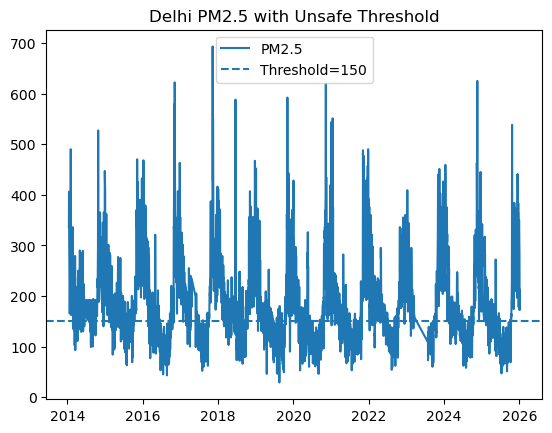

In [ ]:
# ============================================================
# OPTIONAL: Simple visualization for the binary threshold
# ============================================================
plt.figure()
plt.plot(delhi_ml["date"], delhi_ml["pm25"], label="PM2.5")
plt.axhline(PM25_THRESHOLD, linestyle="--", label=f"Threshold={PM25_THRESHOLD}")
plt.title("Delhi PM2.5 with Unsafe Threshold")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, roc_curve, auc

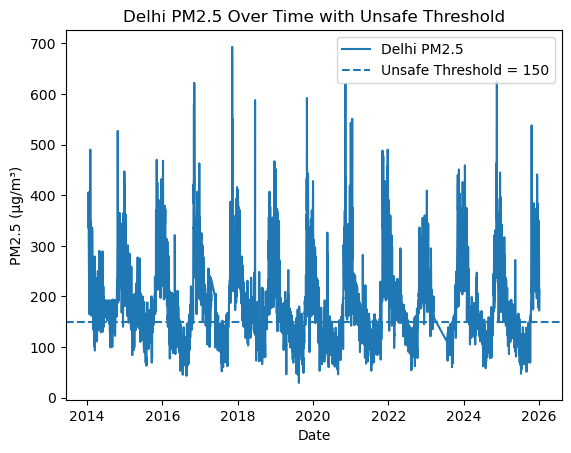

In [ ]:
plt.figure()
plt.plot(delhi_ml["date"], delhi_ml["pm25"], label="Delhi PM2.5")
plt.axhline(PM25_THRESHOLD, linestyle="--", label=f"Unsafe Threshold = {PM25_THRESHOLD}")
plt.title("Delhi PM2.5 Over Time with Unsafe Threshold")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.show()

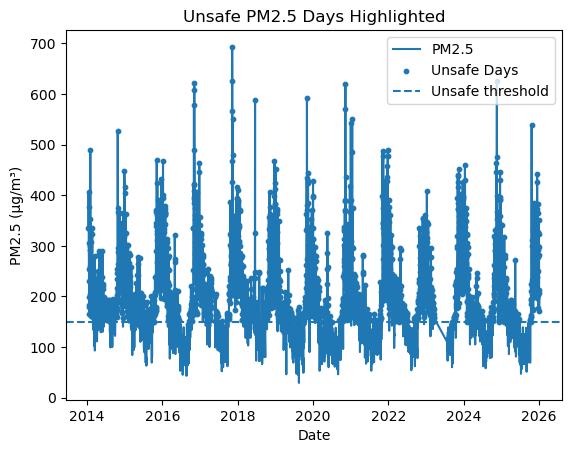

In [ ]:
unsafe_mask = delhi_ml["pm25"] >= PM25_THRESHOLD

plt.figure()
plt.plot(delhi_ml["date"], delhi_ml["pm25"], label="PM2.5")
plt.scatter(delhi_ml.loc[unsafe_mask, "date"],
            delhi_ml.loc[unsafe_mask, "pm25"],
            label="Unsafe Days", s=10)
plt.axhline(PM25_THRESHOLD, linestyle="--", label="Unsafe threshold")
plt.title("Unsafe PM2.5 Days Highlighted")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.show()

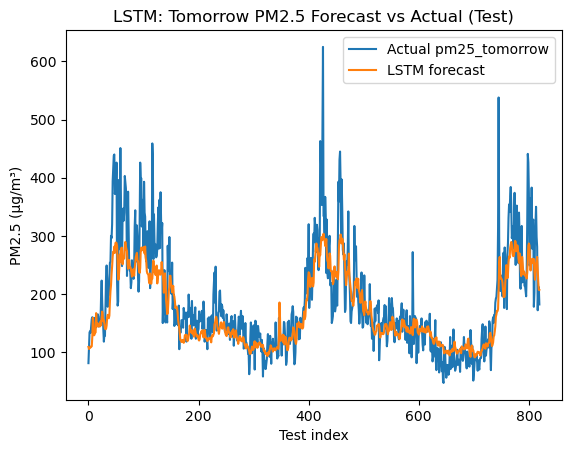

In [ ]:
plt.figure()
plt.plot(y_test_seq, label="Actual pm25_tomorrow")
plt.plot(pred_lstm, label="LSTM forecast")
plt.title("LSTM: Tomorrow PM2.5 Forecast vs Actual (Test)")
plt.xlabel("Test index")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.show()

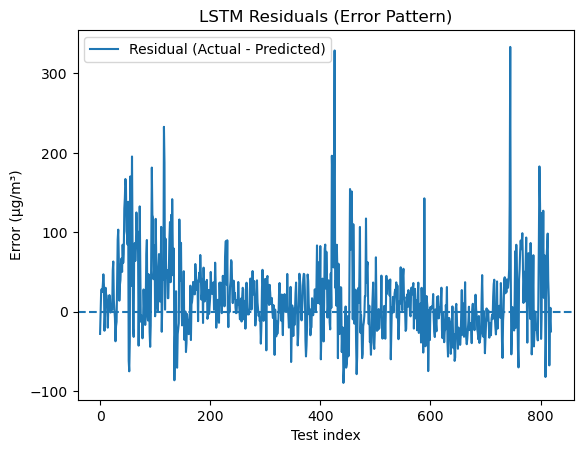

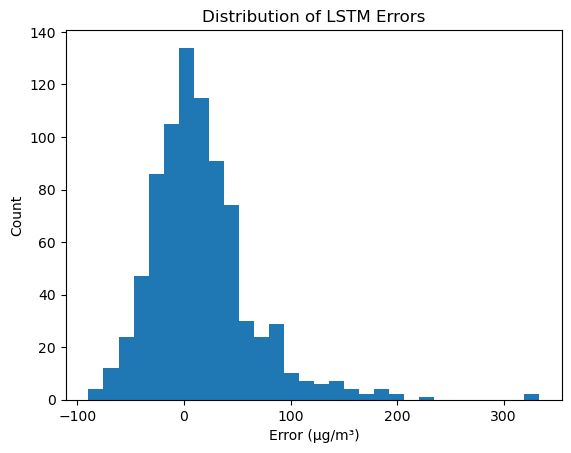

In [ ]:
errors = y_test_seq - pred_lstm

plt.figure()
plt.plot(errors, label="Residual (Actual - Predicted)")
plt.axhline(0, linestyle="--")
plt.title("LSTM Residuals (Error Pattern)")
plt.xlabel("Test index")
plt.ylabel("Error (µg/m³)")
plt.legend()
plt.show()

plt.figure()
plt.hist(errors, bins=30)
plt.title("Distribution of LSTM Errors")
plt.xlabel("Error (µg/m³)")
plt.ylabel("Count")
plt.show()

In [ ]:
print(delhi_ml.columns)

Index(['date', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'month', 'dayofweek',
       'is_winter', 'pm25_lag1', 'pm25_lag7', 'pm25_lag14', 'pm25_roll3',
       'pm25_roll7', 'pm25_roll14', 'pm25_std7', 'pm10_roll7', 'no2_roll7',
       'so2_roll7', 'co_roll7', 'o3_roll7', 'pm25_tomorrow', 'unsafe_tomorrow',
       'isoforest_flag', 'ocsvm_flag', 'is_high_pm25'],
      dtype='object')


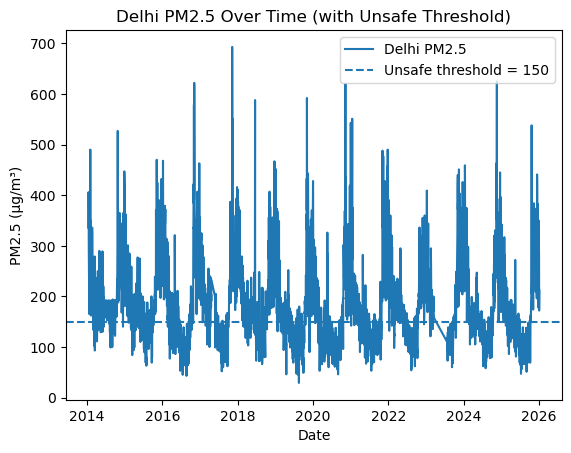

In [ ]:
plt.figure()
plt.plot(delhi_ml["date"], delhi_ml["pm25"], label="Delhi PM2.5")
plt.axhline(PM25_THRESHOLD, linestyle="--", label=f"Unsafe threshold = {PM25_THRESHOLD}")
plt.title("Delhi PM2.5 Over Time (with Unsafe Threshold)")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.show()

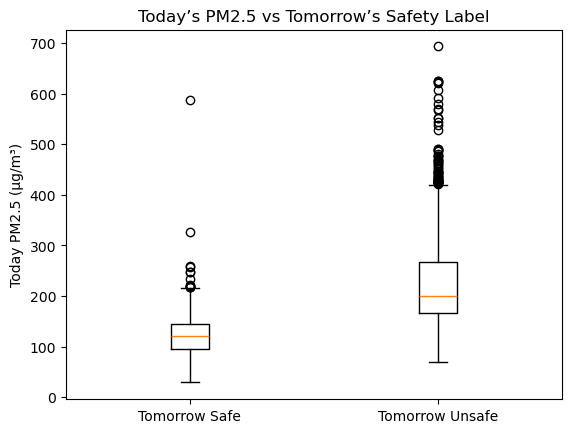

In [ ]:
plt.figure()
data_safe = delhi_ml.loc[delhi_ml["unsafe_tomorrow"]==0, "pm25"].dropna()
data_unsafe = delhi_ml.loc[delhi_ml["unsafe_tomorrow"]==1, "pm25"].dropna()

plt.boxplot([data_safe, data_unsafe], labels=["Tomorrow Safe", "Tomorrow Unsafe"])
plt.title("Today’s PM2.5 vs Tomorrow’s Safety Label")
plt.ylabel("Today PM2.5 (µg/m³)")
plt.show()

In [ ]:
print("Current PM25_THRESHOLD value is:", PM25_THRESHOLD)

Current PM25_THRESHOLD value is: 150


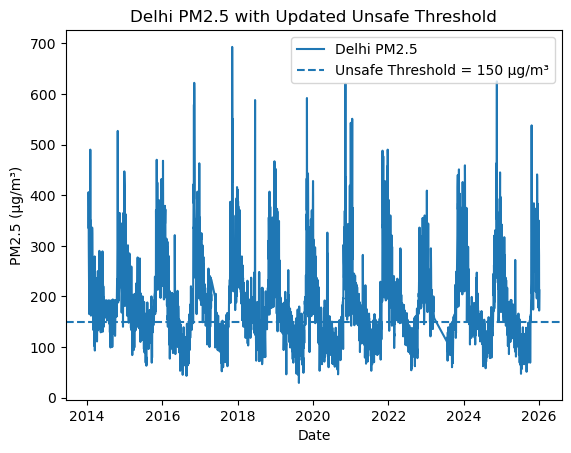

In [ ]:
plt.figure()

plt.plot(delhi_ml["date"], delhi_ml["pm25"], label="Delhi PM2.5")

plt.axhline(
    PM25_THRESHOLD,
    linestyle="--",
    label=f"Unsafe Threshold = {PM25_THRESHOLD} µg/m³"
)

plt.title("Delhi PM2.5 with Updated Unsafe Threshold")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.show()

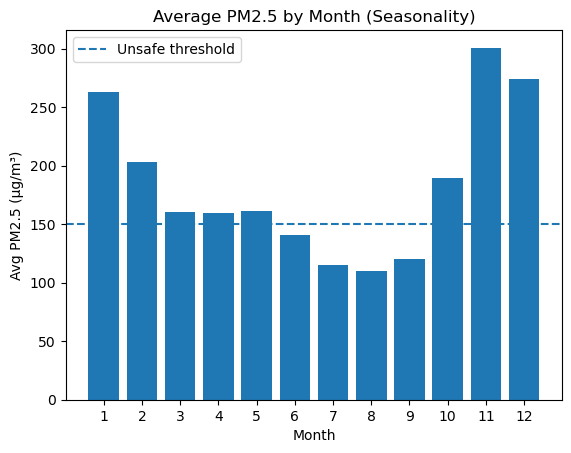

In [ ]:
monthly = delhi_ml.groupby("month")["pm25"].mean()

plt.figure()
plt.bar(monthly.index, monthly.values)
plt.axhline(PM25_THRESHOLD, linestyle="--", label="Unsafe threshold")
plt.title("Average PM2.5 by Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Avg PM2.5 (µg/m³)")
plt.xticks(range(1,13))
plt.legend()
plt.show()

In [ ]:
delhi_ml["unsafe_tomorrow"].value_counts()

unsafe_tomorrow
1    2530
0    1605
Name: count, dtype: int64

In [ ]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os, joblib

APP_FOLDER = os.path.expanduser("/Users/manis/DelhiAirAlertApp")

# Save engineered dataset
delhi_ml.to_csv(os.path.join(APP_FOLDER, "delhi_ml.csv"), index=False)

# Save your trained model that predicts pm25_tomorrow
joblib.dump(rfr, os.path.join(APP_FOLDER, "rfr_model.pkl"))

# Save features list used by the model
with open(os.path.join(APP_FOLDER, "reg_features.txt"), "w") as f:
    for col in REG_FEATURES:
        f.write(col + "\n")

print("✅ Saved to:", APP_FOLDER)
print("Files:", [x for x in os.listdir(APP_FOLDER) if x.endswith(('.csv','.pkl','.txt'))])

✅ Saved to: /Users/manis/DelhiAirAlertApp
Files: ['rfr_model.pkl', 'reg_features.txt', 'delhi_ml.csv']
